# Insurance Fraud Triage: Model, Capacity, and Economics in One Workflow

**The problem.** A claims organisation sees orders of magnitude more incoming claims than its Special Investigations Unit (SIU) can hand-review. The operational question isn't "what is fraud?" — it's **"given fixed investigator capacity, which claims do we send for review, and is that queue producing enough recovered fraud to justify the investigation spend?"** A great model with a bad policy still loses money; a good policy with a weak model sends too many legitimate claims into review and erodes customer experience. This notebook binds model, capacity, and economics into a single decision workflow.

**The approach.** On 18,000 synthetic claims with a realistic fraud-propensity mechanism (claim amount, reporting lag, prior claims, channel, claim type, weekend/night report, and regional effects):

1. Exploratory diagnostics — is fraud risk actually differentiated by claim type and channel?
2. Model benchmark (logistic regression vs. random forest) on ROC-AUC, PR-AUC, and Brier.
3. Calibration curve and **score banding** so an SIU team can operationalise the probability.
4. **Capacity-aware queue simulation** — net benefit (recovered fraud − investigation cost) across investigator capacity ratios.
5. Score-threshold policy curves as an alternative control lever.
6. **Slice-level monitoring** by channel and region — to check that performance is not uneven across operational cuts.

**Audience.** Insurance SIU leads, claims operations, fraud-analytics model validators, and finance partners costing the investigation team's budget.

## 0. Setup and reproducibility

All randomness is seeded so claim simulation, model fits, calibration, capacity-sweep recommendations, and slice-level monitoring reproduce identically across runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(7)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating a claims portfolio

We build 18,000 claims with the covariates a real triage model consumes: claim amount, reporting lag, prior-claim history, tenure, driver age, intake channel, claim type, region, and weekend/night-of-report flags. Fraud propensity is driven by a latent logistic tying those features together. A per-claim `recoverable_amount` is generated so the downstream capacity policy has real monetary levers to optimise against.

In [2]:
n = 18000

claims = pd.DataFrame(
    {
        "claim_amount": np.random.lognormal(mean=8.3, sigma=0.72, size=n),
        "days_to_report": np.random.gamma(shape=2.2, scale=7.0, size=n),
        "num_prior_claims": np.random.poisson(lam=1.2, size=n),
        "policy_tenure_months": np.random.randint(1, 220, size=n),
        "driver_age": np.random.randint(18, 85, size=n),
        "channel": np.random.choice(["agent", "online", "phone", "broker"], p=[0.42, 0.30, 0.16, 0.12], size=n),
        "claim_type": np.random.choice(["auto", "property", "injury", "theft"], p=[0.50, 0.25, 0.15, 0.10], size=n),
        "region": np.random.choice(["North", "South", "East", "West"], p=[0.25, 0.30, 0.22, 0.23], size=n),
    }
)

claims["weekend_report"] = np.random.binomial(1, 0.24, size=n)
claims["night_report"] = np.random.binomial(1, 0.18, size=n)

# Latent fraud propensity
signal = (
    0.00009 * claims["claim_amount"].to_numpy()
    + 0.030 * np.log1p(claims["days_to_report"].to_numpy())
    + 0.24 * np.log1p(claims["num_prior_claims"].to_numpy())
    - 0.0038 * claims["policy_tenure_months"].to_numpy()
    + 0.11 * claims["weekend_report"].to_numpy()
    + 0.10 * claims["night_report"].to_numpy()
    + np.where(claims["channel"].to_numpy() == "online", 0.27, 0.0)
    + np.where(claims["claim_type"].to_numpy() == "injury", 0.34, 0.0)
    + np.where(claims["claim_type"].to_numpy() == "theft", 0.21, 0.0)
    + np.where(claims["region"].to_numpy() == "South", 0.13, 0.0)
    + np.where(claims["driver_age"].to_numpy() < 23, 0.10, 0.0)
)

p_fraud = 1 / (1 + np.exp(-(signal - 1.25)))
claims["is_fraud"] = np.random.binomial(1, p_fraud, size=n)

# Investigation/recovery assumptions
claims["recoverable_amount"] = claims["claim_amount"] * np.random.uniform(0.45, 0.8, size=n)

claims.head()

,claim_amount,days_to_report,num_prior_claims,policy_tenure_months,driver_age,channel,claim_type,region,weekend_report,night_report,is_fraud,recoverable_amount
0,13591.209558,7.639050,1,42,27,agent,auto,North,0,1,1,7085.809908
1,2877.062517,27.504828,0,1,74,agent,theft,East,0,0,0,1516.744530
2,4120.090952,21.046679,1,157,25,agent,auto,West,1,0,0,2180.408176
3,5395.991941,7.751754,1,109,25,agent,theft,West,0,0,0,3276.444701
4,2280.101912,13.958486,3,101,67,agent,property,East,1,0,1,1230.676273


In [3]:
print(f"Claims: {len(claims):,}")
print(f"Fraud prevalence: {claims['is_fraud'].mean():.2%}")
print(f"Avg claim amount: {claims['claim_amount'].mean():.0f}")

Claims: 18,000
Fraud prevalence: 33.26%
Avg claim amount: 5139


## 2. Exploratory fraud diagnostics

Before modelling, we confirm that fraud risk is differentiated by the operational cuts the SIU cares about: claim type and intake channel. If fraud rates were flat across claim type, ranking would add little over a random queue; if flat across channel, the model would add no discriminative power beyond a simple rules-based filter.

In [4]:
fraud_by_type = (
    claims.groupby("claim_type", as_index=False)
    .agg(fraud_rate=("is_fraud", "mean"), n_claims=("is_fraud", "size"), avg_amount=("claim_amount", "mean"))
    .sort_values("fraud_rate", ascending=False)
)

fraud_by_channel = (
    claims.groupby("channel", as_index=False)
    .agg(fraud_rate=("is_fraud", "mean"), n_claims=("is_fraud", "size"))
    .sort_values("fraud_rate", ascending=False)
)

fraud_by_type, fraud_by_channel

(  claim_type  fraud_rate  n_claims   avg_amount
 1     injury    0.393563      2734  5120.968332
 3      theft    0.355747      1740  5100.416124
 0       auto    0.317626      8913  5141.700917
 2   property    0.316497      4613  5158.795547,
   channel  fraud_rate  n_claims
 2  online    0.369743      5493
 0   agent    0.318756      7523
 3   phone    0.316811      2885
 1  broker    0.306336      2099)

C:\Users\diogo\AppData\Local\Temp\ipykernel_12228\957164664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_type, x="claim_type", y="fraud_rate", ax=ax[0], palette="Reds")
C:\Users\diogo\AppData\Local\Temp\ipykernel_12228\957164664.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fraud_by_channel, x="channel", y="fraud_rate", ax=ax[1], palette="Blues")


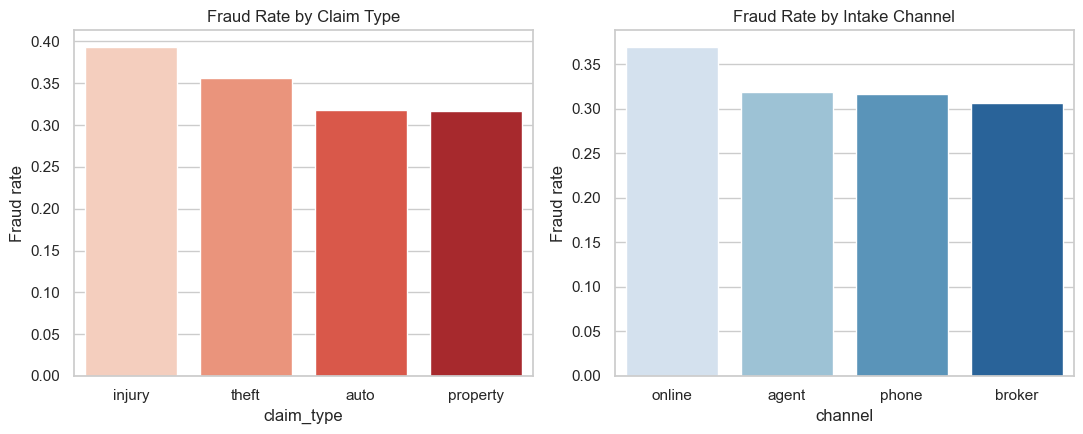

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(data=fraud_by_type, x="claim_type", y="fraud_rate", ax=ax[0], palette="Reds")
ax[0].set_title("Fraud Rate by Claim Type")
ax[0].set_ylabel("Fraud rate")

sns.barplot(data=fraud_by_channel, x="channel", y="fraud_rate", ax=ax[1], palette="Blues")
ax[1].set_title("Fraud Rate by Intake Channel")
ax[1].set_ylabel("Fraud rate")

plt.tight_layout()
plt.show()

**What to read here.** The left panel should show injury and theft claims at elevated fraud rates — those are the classical fraud concentrations a claims team expects. The right panel surfaces online intake as a higher-risk channel, often because it lacks the in-person friction of an agent interaction. Flat bars across either dimension would be a red flag: the model would have limited lift over a random queue, and the rest of the notebook would be overbuilding on a weak signal.

## 3. Data split and preprocessing

A 75/25 split **stratified on fraud** keeps rare-positive representation stable in holdout. Numeric features are standardised; categoricals are one-hot encoded. Stratification matters more here than in balanced classification: a fraud rate of 5–10% in an unstratified 25% test set can easily be off by a factor that misleads calibration.

In [6]:
features = [
    "claim_amount",
    "days_to_report",
    "num_prior_claims",
    "policy_tenure_months",
    "driver_age",
    "channel",
    "claim_type",
    "region",
    "weekend_report",
    "night_report",
]

target = "is_fraud"

X = claims[features]
y = claims[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

num_cols = [
    "claim_amount",
    "days_to_report",
    "num_prior_claims",
    "policy_tenure_months",
    "driver_age",
    "weekend_report",
    "night_report",
]
cat_cols = ["channel", "claim_type", "region"]

prep = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

## 4. Model benchmark: logistic vs. random forest

Two intentionally different learners:

- **Logistic regression** — the reference model. Interpretable, defensible to an SIU lead who wants to see feature weights, tends to under-fit non-linearities (e.g. fraud spikes in specific claim-type × channel interactions).
- **Random forest** — handles those interactions automatically at the cost of interpretability (recoverable via SHAP or permutation importance if needed for governance).

Three metrics — ROC-AUC for rank, PR-AUC for the rare-positive regime we actually care about, and Brier for probability quality. Sorted by **PR-AUC** rather than ROC-AUC, because at 5–10% prevalence PR-AUC is the honest number.

In [7]:
logit = Pipeline(
    steps=[
        ("prep", prep),
        ("clf", LogisticRegression(max_iter=500, random_state=7)),
    ]
)

rf = Pipeline(
    steps=[
        ("prep", prep),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=350,
                max_depth=10,
                min_samples_leaf=10,
                random_state=7,
                n_jobs=-1,
            ),
        ),
    ]
)

logit.fit(X_train, y_train)
rf.fit(X_train, y_train)

preds = {
    "Logistic": logit.predict_proba(X_test)[:, 1],
    "RandomForest": rf.predict_proba(X_test)[:, 1],
}

rows = []
for name, p in preds.items():
    rows.append(
        {
            "model": name,
            "roc_auc": roc_auc_score(y_test, p),
            "pr_auc": average_precision_score(y_test, p),
            "brier": brier_score_loss(y_test, p),
        }
    )

metrics = pd.DataFrame(rows).sort_values("pr_auc", ascending=False)
metrics

,model,roc_auc,pr_auc,brier
0,Logistic,0.638199,0.472127,0.209598
1,RandomForest,0.634012,0.465306,0.210629


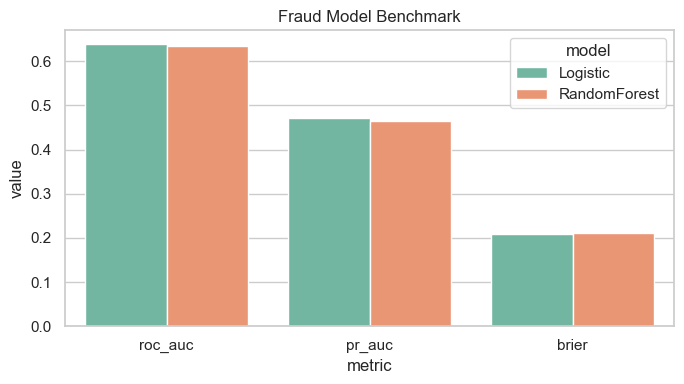

In [8]:
plt.figure(figsize=(7, 4))
plot_df = metrics.melt(id_vars="model", value_vars=["roc_auc", "pr_auc", "brier"], var_name="metric")
sns.barplot(data=plot_df, x="metric", y="value", hue="model", palette="Set2")
plt.title("Fraud Model Benchmark")
plt.tight_layout()
plt.show()

**What to read here.** Compare the PR-AUC bars first — that is the metric most aligned with the SIU's operational reality (rare positives in a large stream). A visible PR-AUC gap with a modest ROC-AUC gap is the signature of a flexible model earning real lift in the high-score region of the queue. If Brier is also lower for that model, it is the candidate to take through calibration and into the capacity policy.

## 5. Calibration and score bands

Calibration is the bridge between probability and policy. An SIU team operates on bands — "high risk", "medium risk", "low risk" — and bands only mean what their label says if the underlying probabilities are calibrated. We check the calibration curve, then bucket test-set scores into deciles and compare observed fraud rate per decile to the average predicted score.

Champion model: Logistic
ROC-AUC=0.638 | PR-AUC=0.472


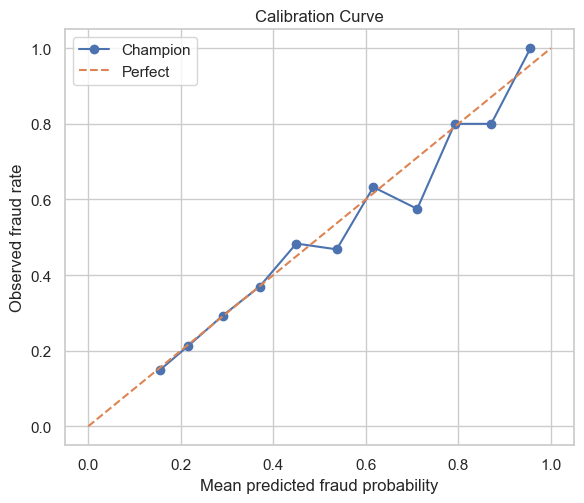

In [9]:
champion_name = metrics.iloc[0]["model"]
champion = logit if champion_name == "Logistic" else rf
proba_test = preds[champion_name]

print(f"Champion model: {champion_name}")
print(f"ROC-AUC={roc_auc_score(y_test, proba_test):.3f} | PR-AUC={average_precision_score(y_test, proba_test):.3f}")

frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=12)

plt.figure(figsize=(6, 5.2))
plt.plot(mean_pred, frac_pos, marker="o", label="Champion")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect")
plt.xlabel("Mean predicted fraud probability")
plt.ylabel("Observed fraud rate")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

**What to read here.** A calibration curve hugging the 45° line means an SIU band labelled "30% fraud likelihood" actually delivers ~30% fraud at review. Random forests often show mild under-confidence at the high end and over-confidence at the low end — that pattern is what Platt or isotonic post-calibration is designed to fix if the bands need to land exactly. The score-band table below operationalises this: if decile 9 shows a 40%+ observed fraud rate while decile 0 is ~1%, the score is doing what SIU needs it to do.

In [10]:
score_band = pd.DataFrame({"score": proba_test, "label": y_test.values})
score_band["band"] = pd.qcut(score_band["score"], q=10, labels=False, duplicates="drop")
band_summary = (
    score_band.groupby("band", as_index=False)
    .agg(avg_score=("score", "mean"), obs_fraud_rate=("label", "mean"), n=("label", "size"))
    .sort_values("band")
)
band_summary

,band,avg_score,obs_fraud_rate,n
0,0,0.188351,0.151111,450
1,1,0.226052,0.237778,450
2,2,0.252610,0.248889,450
3,3,0.276706,0.320000,450
4,4,0.300799,0.286667,450
5,5,0.325909,0.317778,450
6,6,0.354310,0.342222,450
7,7,0.389248,0.386667,450
8,8,0.439333,0.488889,450
9,9,0.580689,0.546667,450


**What to read here.** The score-band table is the operational handoff to SIU. The `obs_fraud_rate` column should rise monotonically across bands — otherwise the score is non-monotone at some point and the band labels won't mean what they say. A high top-band observed rate (e.g. band 9 ≫ band 0) is the one-number summary of ranking quality.

## 6. Capacity-constrained triage simulation

This is where the model meets the operation. The SIU can only review a fixed *share* of incoming claims (capacity ratio) — typically 2–15% depending on staffing. For each capacity level we rank claims by score, review the top *k*, and compute **net benefit**: expected recovery (fraud catches × recoverable amount × recovery rate) minus investigation spend (*k* × cost per investigation). The optimum isn't 100% capacity — it is the point where the marginal investigation no longer pays for itself.

In [11]:
test_df = X_test.copy()
test_df["label"] = y_test.values
test_df["score"] = proba_test
test_df["recoverable_amount"] = claims.loc[test_df.index, "recoverable_amount"]

def evaluate_policy(df: pd.DataFrame, capacity_ratio: float, investigation_cost: float = 180.0, recovery_rate: float = 0.62):
    k = int(len(df) * capacity_ratio)
    ranked = df.sort_values("score", ascending=False).head(k)

    tp = int((ranked["label"] == 1).sum())
    fp = int((ranked["label"] == 0).sum())
    total_fraud = int(df["label"].sum())

    precision = tp / max(k, 1)
    recall = tp / max(total_fraud, 1)

    expected_recovery = (ranked.loc[ranked["label"] == 1, "recoverable_amount"].sum()) * recovery_rate
    investigation_spend = k * investigation_cost
    net_benefit = expected_recovery - investigation_spend

    return {
        "capacity_ratio": capacity_ratio,
        "n_reviewed": k,
        "tp_detected": tp,
        "fp_reviewed": fp,
        "precision": precision,
        "recall": recall,
        "expected_recovery": expected_recovery,
        "investigation_spend": investigation_spend,
        "net_benefit": net_benefit,
    }

capacity_grid = [0.02, 0.03, 0.05, 0.08, 0.10, 0.12, 0.15]
policy_table = pd.DataFrame([evaluate_policy(test_df, c) for c in capacity_grid])
policy_table

,capacity_ratio,n_reviewed,tp_detected,fp_reviewed,precision,recall,expected_recovery,investigation_spend,net_benefit
0,0.02,90,64,26,0.711111,0.042752,5.708714e+05,16200.0,5.546714e+05
1,0.03,135,92,43,0.681481,0.061456,7.254200e+05,24300.0,7.011200e+05
2,0.05,225,136,89,0.604444,0.090848,9.431960e+05,40500.0,9.026960e+05
3,0.08,360,201,159,0.558333,0.134269,1.229588e+06,64800.0,1.164788e+06
4,0.10,450,246,204,0.546667,0.164329,1.369860e+06,81000.0,1.288860e+06
5,0.12,540,289,251,0.535185,0.193053,1.521374e+06,97200.0,1.424174e+06
6,0.15,675,361,314,0.534815,0.241149,1.712901e+06,121500.0,1.591401e+06


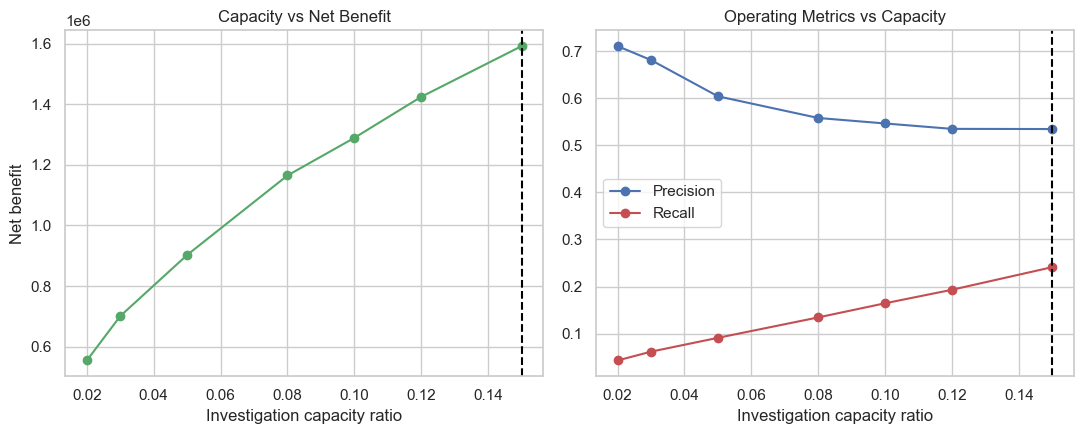

Best capacity ratio: 15% | Reviewed=675 | Net benefit=1591401


In [12]:
best_policy = policy_table.sort_values("net_benefit", ascending=False).iloc[0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].plot(policy_table["capacity_ratio"], policy_table["net_benefit"], marker="o", color="#55A868")
ax[0].axvline(best_policy["capacity_ratio"], linestyle="--", color="black")
ax[0].set_title("Capacity vs Net Benefit")
ax[0].set_xlabel("Investigation capacity ratio")
ax[0].set_ylabel("Net benefit")

ax[1].plot(policy_table["capacity_ratio"], policy_table["precision"], marker="o", label="Precision", color="#4C72B0")
ax[1].plot(policy_table["capacity_ratio"], policy_table["recall"], marker="o", label="Recall", color="#C44E52")
ax[1].axvline(best_policy["capacity_ratio"], linestyle="--", color="black")
ax[1].set_title("Operating Metrics vs Capacity")
ax[1].set_xlabel("Investigation capacity ratio")
ax[1].legend()

plt.tight_layout()
plt.show()

print(
    f"Best capacity ratio: {best_policy['capacity_ratio']:.0%} | "
    f"Reviewed={int(best_policy['n_reviewed'])} | "
    f"Net benefit={best_policy['net_benefit']:.0f}"
)

**What to read here.** The left panel is the headline: net benefit rises from low capacity (too few reviews; leave money on the table), peaks at the operational sweet spot, then declines as additional capacity starts reviewing mostly false positives. The right panel shows the operating-metric cost of that sweet spot — precision falls and recall rises with capacity, and the dashed optimum line shows exactly where the SIU should sit. If capacity is constrained below the optimum, this plot is the business case for hiring; if it's above, it is the case for reallocating.

## 7. Score-threshold policy view

Capacity ratios are one control lever; score thresholds are another. Some organisations prefer to route "any score above 0.5" regardless of volume — useful when investigator capacity is elastic or when downstream automation absorbs overflow. The curves below show the tradeoff: lower thresholds sweep in more claims (higher review rate), with falling precision and rising recall.

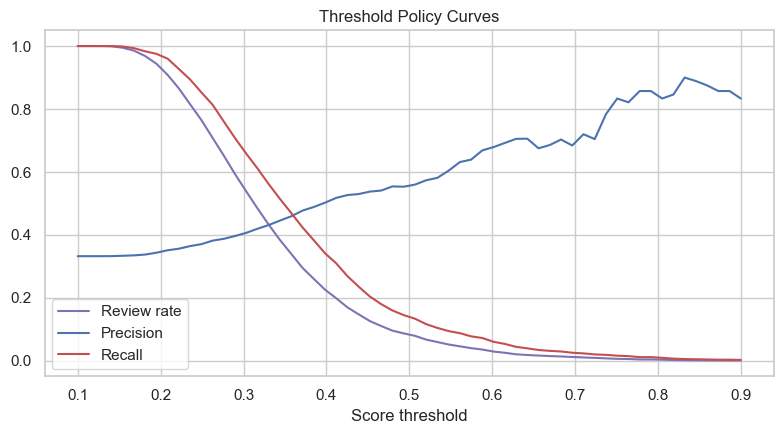

In [13]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_test)

th_rows = []
for t in np.linspace(0.10, 0.90, 60):
    pred = (proba_test >= t).astype(int)
    tp = int(((pred == 1) & (y_test.values == 1)).sum())
    fp = int(((pred == 1) & (y_test.values == 0)).sum())
    fn = int(((pred == 0) & (y_test.values == 1)).sum())

    th_rows.append(
        {
            "threshold": t,
            "review_rate": pred.mean(),
            "precision": tp / max(tp + fp, 1),
            "recall": tp / max(tp + fn, 1),
        }
    )

th_table = pd.DataFrame(th_rows)

plt.figure(figsize=(8, 4.5))
plt.plot(th_table["threshold"], th_table["review_rate"], label="Review rate", color="#8172B2")
plt.plot(th_table["threshold"], th_table["precision"], label="Precision", color="#4C72B0")
plt.plot(th_table["threshold"], th_table["recall"], label="Recall", color="#C44E52")
plt.xlabel("Score threshold")
plt.title("Threshold Policy Curves")
plt.legend()
plt.tight_layout()
plt.show()

**What to read here.** The purple line is the share of incoming claims flagged for review at each threshold; the blue and red lines are precision and recall. A business that budgets by *share of claims reviewed* should start from the purple line and work outward; a business that budgets by *fraud loss avoided* should start from the red (recall) line. The intersection of precision and recall is the classical F1-equal point — useful as a sanity check but almost never the right policy target.

## 8. Slice-level monitoring (channel and region)

Aggregate performance can mask uneven behaviour across operational segments. We recompute precision-at-capacity for each channel and region, and express it as **lift** over each slice's base fraud rate. Lift close to 1.0 means the model is barely adding value in that slice; much higher lift means the model is earning its keep there. Large disparities are an operational flag (is the model working worse for some channels?) and sometimes a fairness flag depending on what the slices represent.

In [14]:
# Evaluate uplift from model ranking in each operational slice
selected_ratio = float(best_policy["capacity_ratio"])

slice_rows = []
for dim in ["channel", "region"]:
    for value, grp in test_df.groupby(dim):
        k = int(len(grp) * selected_ratio)
        if k < 1:
            continue
        ranked = grp.sort_values("score", ascending=False).head(k)

        slice_rows.append(
            {
                "dimension": dim,
                "slice": value,
                "n": len(grp),
                "base_fraud_rate": grp["label"].mean(),
                "precision_at_capacity": ranked["label"].mean(),
                "lift": ranked["label"].mean() / max(grp["label"].mean(), 1e-9),
            }
        )

slice_perf = pd.DataFrame(slice_rows).sort_values(["dimension", "lift"], ascending=[True, False])
slice_perf

,dimension,slice,n,base_fraud_rate,precision_at_capacity,lift
1,channel,broker,523,0.305927,0.551282,1.802003
0,channel,agent,1853,0.316784,0.534296,1.686628
3,channel,phone,725,0.304828,0.462963,1.518770
2,channel,online,1399,0.378127,0.555024,1.467823
4,region,East,989,0.310415,0.513514,1.654283
7,region,West,1010,0.332673,0.529801,1.592558
5,region,North,1107,0.346883,0.548193,1.580337
6,region,South,1394,0.337159,0.511962,1.518457


C:\Users\diogo\AppData\Local\Temp\ipykernel_12228\1813339746.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="slice", y="lift", palette="mako")


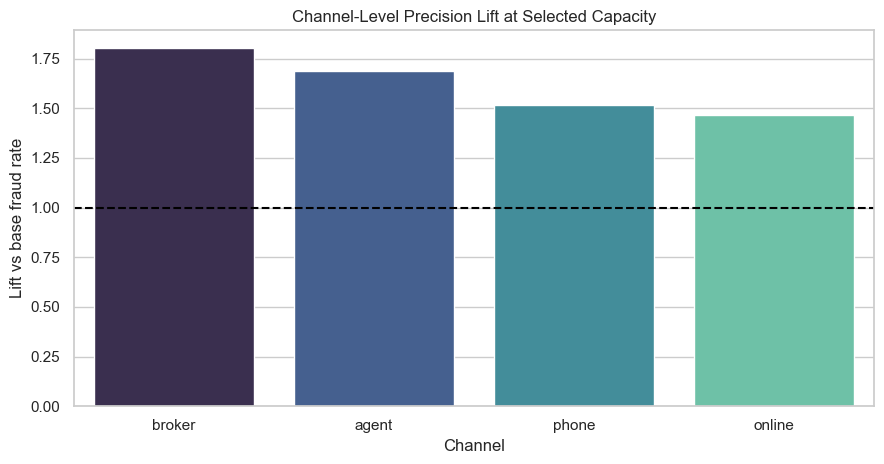

In [15]:
plt.figure(figsize=(9, 4.8))
plot_df = slice_perf[slice_perf["dimension"] == "channel"].copy()
sns.barplot(data=plot_df, x="slice", y="lift", palette="mako")
plt.axhline(1.0, linestyle="--", color="black")
plt.title("Channel-Level Precision Lift at Selected Capacity")
plt.ylabel("Lift vs base fraud rate")
plt.xlabel("Channel")
plt.tight_layout()
plt.show()

**What to read here.** Bars well above the dashed 1.0 line mean the model is adding real lift in that channel — that channel should stay on the model queue. Bars close to 1.0 are channels where the model barely beats random ranking; those warrant investigation (are important features missing for that channel? is the training data under-representing it?). A channel below 1.0 means the model is *actively worse* than a random queue there — a hard stop requiring retraining or carving the channel out entirely.

## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- Fraud triage is not a classification problem — it is a *ranked queue under capacity*, and the right metric is net benefit, not F1.
- PR-AUC matters more than ROC-AUC when fraud prevalence is low; Brier matters when the score is operationalised into bands.
- The capacity-sweep curve is the business case the SIU team should present for its headcount: it shows where net benefit peaks and how steep the drop-off is on either side.
- Slice-level lift is a first-class monitoring artefact. A model with great aggregate performance and a single channel below 1.0 is still a problem.

**Limitations**

- Investigation cost, recovery rate, and per-claim recoverable amount are all assumptions. A production version needs real SIU throughput data, historical recovery rates, and a calibration of the recoverable-amount distribution to actual recovery outcomes.
- The model is static. Fraud typology shifts; concept drift detection (PSI on inputs, calibration monitoring, ongoing re-training triggers) is essential.
- Capacity is modelled as a fixed ratio. Real SIU capacity is a queue with SLAs, backlog dynamics, and investigator skill mix that a discrete-event simulation would capture more faithfully.
- The slice-monitoring view treats channel and region as operational segments. When those slices overlap with protected attributes (indirectly or directly), formal fairness analysis — equality-of-opportunity, demographic-parity gap, calibration-within-group — is required, not just lift comparison.

**What a production version would add**

- **SHAP** for investigator-facing "why was this flagged?" explanations and validator-facing model audit.
- **Platt or isotonic calibration** if score bands need to land precisely.
- **Bandit-style exploration** to avoid the cold-start problem when fraud typology shifts and the top-scoring claims stop being the true fraud concentration.
- **Discrete-event queue simulation** for realistic SIU throughput and backlog planning.
- **Drift monitoring dashboards** (PSI, CSI, calibration, slice lift) with a documented re-training policy.